# Exploratory Data Analysis (EDA)

Before we do anything with our data, we should first perform exploratory data analysis (EDA). Our goal is to use the tabular data provided to us and predict the probability of a pitstop next lap. We will evaluate our models using AUC metric.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from data.utils import plot_features_dual_axis
from data.utils import plot_train_test_distributions

In [2]:
train = pd.read_csv("data/train.csv")
print("Train shape:", train.shape )
train.head(1)

Train shape: (439140, 16)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0


In [3]:
test = pd.read_csv("data/test.csv")
print("Test shape:", test.shape )
test.head(1)

Test shape: (188165, 15)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.28,-4.984,0.403846,0.0


# Basic EDA

For basic EDA, we can view a bar chart of the target to understand the distribution. Also we can check each feature's histogram, unique value count, and nan count. For each feature we determine if it is categorical or numeric. Most importantly we want to look at the relationship between each feature and target.

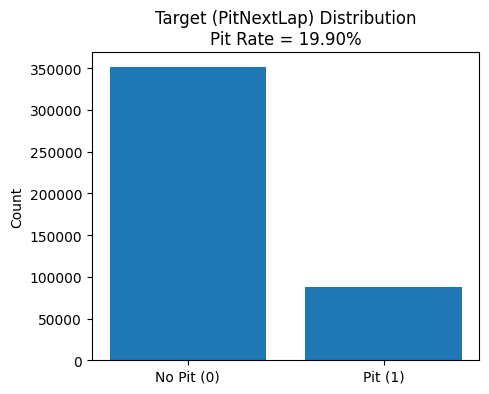

In [4]:
counts = train["PitNextLap"].value_counts()
m = train["PitNextLap"].mean()
plt.figure(figsize=(5,4))
plt.bar(["No Pit (0)", "Pit (1)"], [counts[0], counts[1]])
plt.title(f"Target (PitNextLap) Distribution\nPit Rate = {m:.2%}")
plt.ylabel("Count")
plt.show()

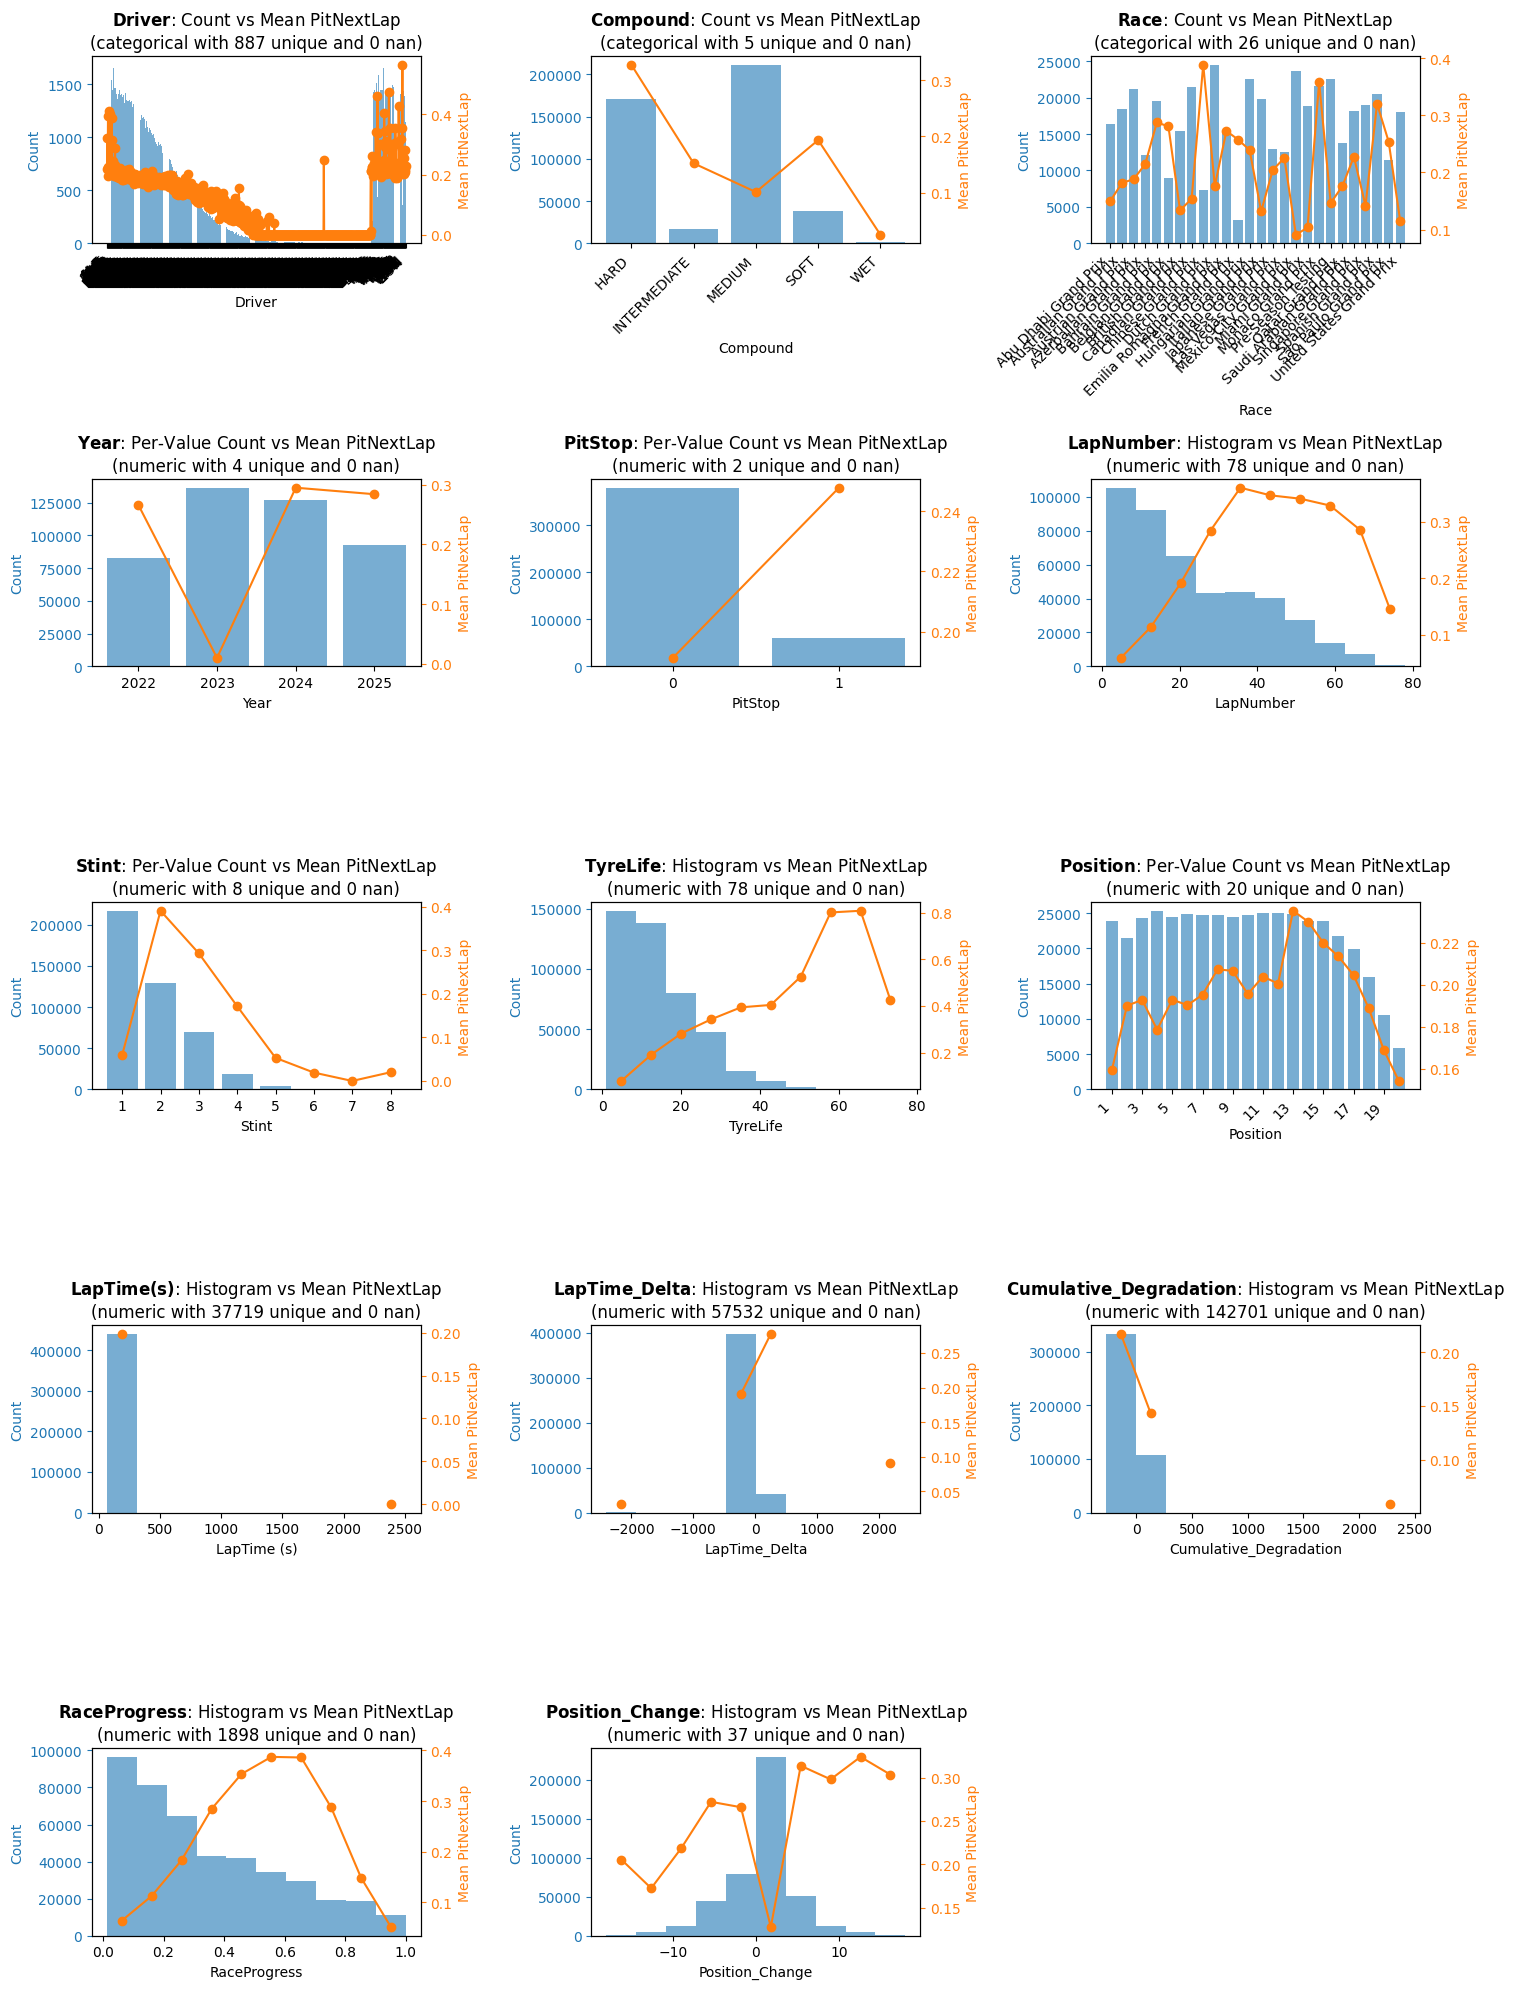

In [5]:
plot_features_dual_axis(
    train,
    cols=train.columns[1:-1],
    target_col="PitNextLap",
    n_bins=10,
    n_wide=3,
    int_as_cat_unique_max=20,
    cat_order = None,
)

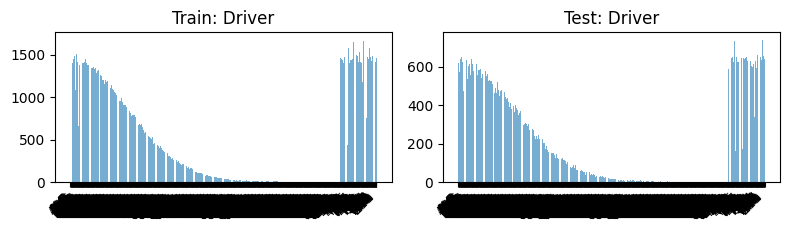

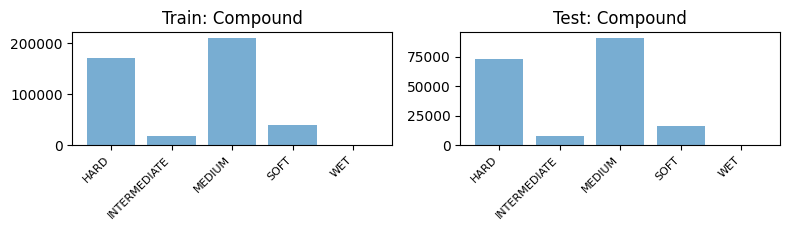

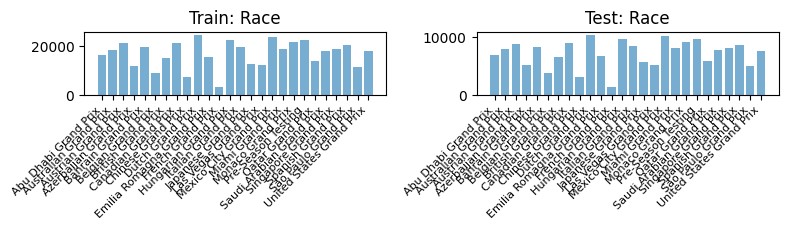

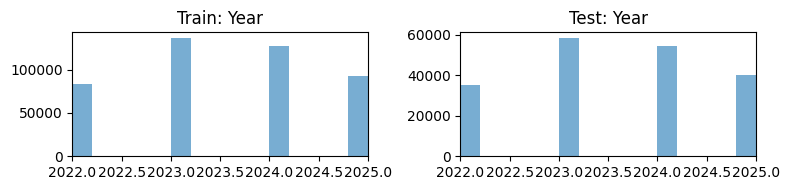

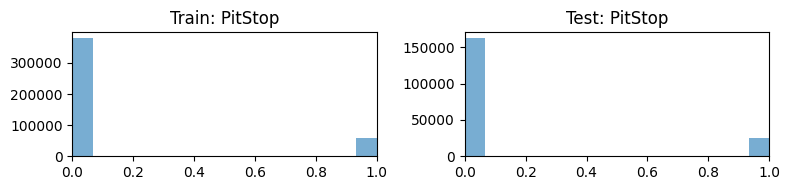

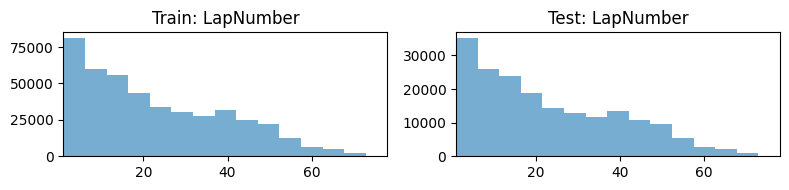

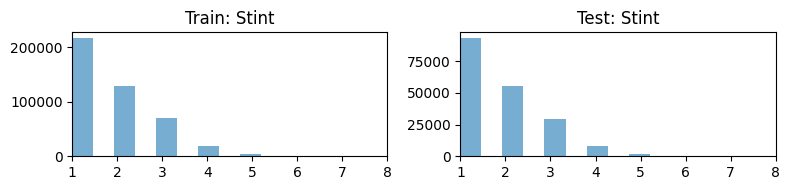

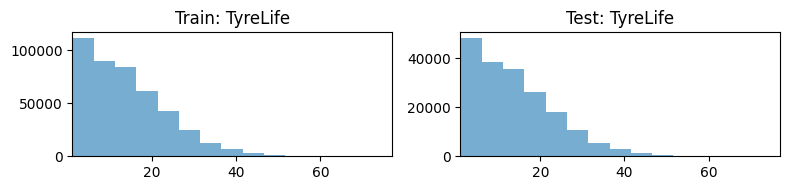

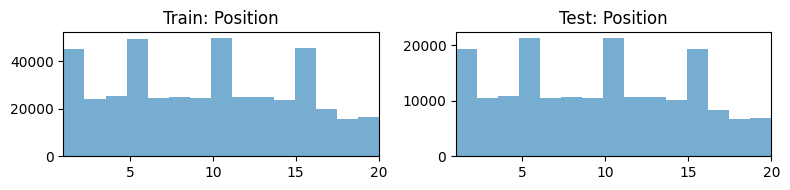

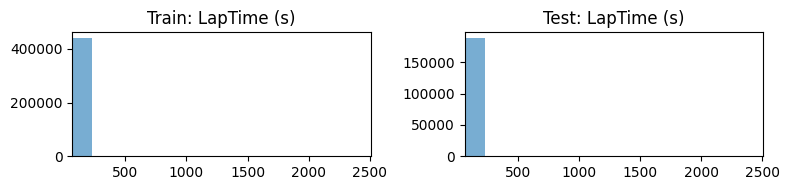

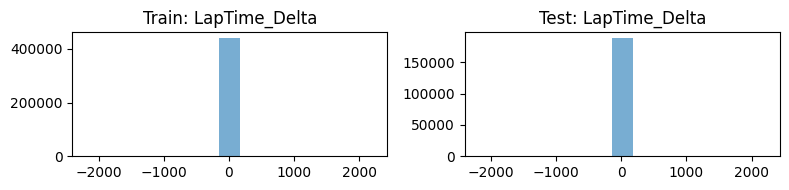

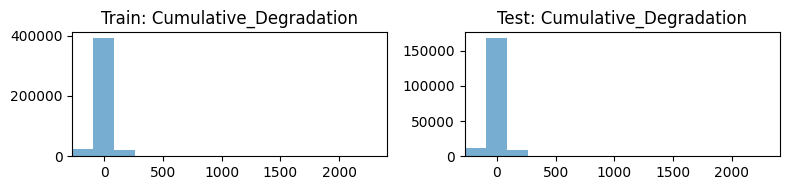

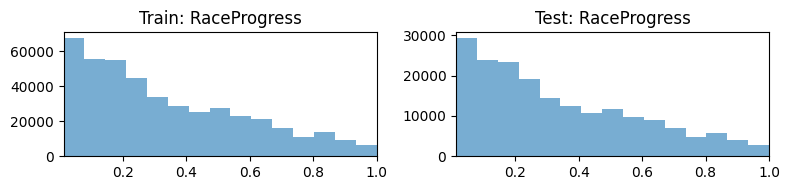

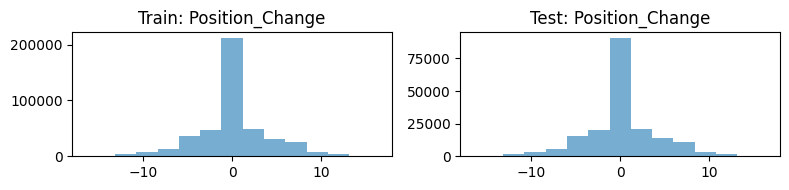

In [6]:
plot_train_test_distributions(
    train, 
    test, 
    train.columns[1:-1], 
    n_bins=15
)